# Exploratory Data Analysis - SaaS Sales Conversations

**Dataset:** [DeepMostInnovations/saas-sales-conversations](https://huggingface.co/datasets/DeepMostInnovations/saas-sales-conversations)

---

## Overview

This notebook performs a comprehensive Exploratory Data Analysis on the **SaaS Sales Conversations** dataset - a synthetic corpus of B2B sales dialogues engineered for training sales-conversion prediction models. Each row is a full conversation between a sales representative and a prospect, enriched with behavioural scores, contextual metadata, and 3072-dimensional text embeddings.

### Goals

| # | Goal |
|---|------|
| 1 | Understand schema, data types, and dataset scale |
| 2 | Audit data quality - missingness, duplicates, type anomalies |
| 3 | Profile the target variable (`outcome`) and quantify class imbalance |
| 4 | Characterise distributions of continuous features mathematically |
| 5 | Uncover non-obvious patterns that constrain modelling choices |
| 6 | Detect potential data leakage risks from derived features |
| 7 | Translate every EDA finding into a direct modelling implication |

### Column Groups

| Group | Columns |
|---|---|
| **Identity** | `company_id`, `company_name`, `product_name`, `product_type`, `conversation_id` |
| **Content** | `scenario`, `conversation`, `full_text` |
| **Target** | `outcome` — binary (0 = no conversion, 1 = conversion) |
| **Behavioural Scores** | `customer_engagement`, `sales_effectiveness` |
| **Structural** | `conversation_length`, `conversation_style`, `conversation_flow`, `communication_channel` |
| **Embeddings** | `embedding_0` … `embedding_3071` (3072-dim dense vector) |

---
## 1. Setup & Imports

In [1]:
import warnings
import json
import re
from itertools import islice

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from datasets import load_dataset

np.random.seed(42)

PALETTE = ["#1D3557", "#E63946", "#457B9D", "#A8DADC", "#F4A261", "#2A9D8F", "#E9C46A"]
ACCENT  = "#1D3557"
ACCENT2 = "#E63946"

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "DejaVu Sans",
})

print("Environment ready.")

Environment ready.


---
## 2. Data Loading

The full dataset is ~7 GB. `streaming=True` with `islice` samples 8,000 rows without materialising the whole file - sufficient for robust distributional analysis.

In [2]:
# Login using e.g. huggingface-cli login to access this dataset
SAMPLE_SIZE = 8000

ds_stream = load_dataset(
    "DeepMostInnovations/saas-sales-conversations",
    streaming=True,
)

split_name = list(ds_stream.keys())[0]
print(f"Streaming split: {split_name}")

records = list(islice(ds_stream[split_name], SAMPLE_SIZE))
df = pd.DataFrame(records)
print(f"Sampled {len(df):,} rows x {df.shape[1]:,} columns")

Streaming split: train


Sampled 8,000 rows x 3,088 columns


In [3]:
emb_cols  = [c for c in df.columns if c.startswith("embedding_")]
meta_cols = [c for c in df.columns if c not in emb_cols]

print(f"Metadata columns : {len(meta_cols)}")
print(f"Embedding columns: {len(emb_cols)} (dim = {len(emb_cols)})")

Metadata columns : 16
Embedding columns: 3072 (dim = 3072)


---
## 3. Schema Inspection

In [4]:
dtype_df = df[meta_cols].dtypes.reset_index()
dtype_df.columns = ["Column", "dtype"]
dtype_df["Unique"]   = [df[c].nunique() for c in meta_cols]
dtype_df["Missing"]  = [df[c].isna().sum() for c in meta_cols]
dtype_df["Missing%"] = (dtype_df["Missing"] / len(df) * 100).round(2)
print(dtype_df.to_string(index=False))

                Column   dtype  Unique  Missing  Missing%
            company_id     str       2        0       0.0
          company_name     str       2        0       0.0
          product_name     str       2        0       0.0
          product_type     str       2        0       0.0
       conversation_id     str    8000        0       0.0
              scenario     str    8000        0       0.0
          conversation     str    8000        0       0.0
             full_text     str    8000        0       0.0
               outcome   int64       2        0       0.0
   conversation_length   int64      13        0       0.0
   customer_engagement float64      15        0       0.0
   sales_effectiveness float64      18        0       0.0
probability_trajectory     str    6878        0       0.0
    conversation_style     str      10        0       0.0
     conversation_flow     str      16        0       0.0
 communication_channel     str       7        0       0.0


---
## 4. Data Quality Audit

In [5]:
missing = df[meta_cols].isna().sum()
print("=== Missing Values (metadata columns) ===")
if missing.any():
    print(missing[missing > 0])
else:
    print("No missing values in metadata columns.")

n_dups = df.duplicated().sum()
print(f"\nFull-row duplicates: {n_dups}")

if "conversation_id" in df.columns:
    n_dup_ids = df["conversation_id"].duplicated().sum()
    print(f"Duplicate conversation_ids: {n_dup_ids}")

=== Missing Values (metadata columns) ===
No missing values in metadata columns.



Full-row duplicates: 0
Duplicate conversation_ids: 0


In [6]:
print("=== Range Checks ===")
for col in ["customer_engagement", "sales_effectiveness"]:
    if col in df.columns:
        oob = ((df[col] < 0) | (df[col] > 1)).sum()
        print(f"{col}: {oob} values outside [0, 1]")

if "outcome" in df.columns:
    valid = df["outcome"].isin([0, 1]).all()
    print(f"outcome strictly binary: {valid}")

if "conversation_length" in df.columns:
    neg = (df["conversation_length"] <= 0).sum()
    print(f"conversation_length <= 0: {neg}")

=== Range Checks ===
customer_engagement: 0 values outside [0, 1]
sales_effectiveness: 0 values outside [0, 1]
outcome strictly binary: True
conversation_length <= 0: 0


---
## 5. Statistical Summary

In [7]:
num_cols = [c for c in meta_cols
            if pd.api.types.is_numeric_dtype(df[c]) and c != "outcome"]

summary = df[num_cols].describe().T
summary["skewness"] = df[num_cols].skew().round(3)
summary["kurtosis"] = df[num_cols].kurtosis().round(3)
summary["cv"]       = (summary["std"] / summary["mean"]).round(3)

display(summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis", "cv"]])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
conversation_length,8000.0,12.044875,1.495290,8.0,11.0,12.0,13.00,30.0,0.366,2.057,0.124
customer_engagement,8000.0,0.638974,0.118117,0.2,0.6,0.7,0.70,0.9,-0.518,-0.472,0.185
sales_effectiveness,8000.0,0.606470,0.156380,0.3,0.5,0.6,0.75,0.9,-0.123,-1.229,0.258


---
## 6. Target Variable — Outcome Distribution

In [8]:
outcome_counts = df["outcome"].value_counts().sort_index()
outcome_pct    = (outcome_counts / len(df) * 100).round(2)

print("=== Target Class Distribution ===")
for cls, cnt, pct in zip(outcome_counts.index, outcome_counts.values, outcome_pct.values):
    label = "Converted" if cls == 1 else "Not Converted"
    print(f"  {cls} ({label:>14s}): {cnt:>6,}  ({pct:.2f}%)")

imb_ratio = outcome_counts.max() / outcome_counts.min()
print(f"\nImbalance ratio (majority / minority): {imb_ratio:.2f}x")

=== Target Class Distribution ===
  0 ( Not Converted):  4,001  (50.01%)
  1 (     Converted):  3,999  (49.99%)

Imbalance ratio (majority / minority): 1.00x


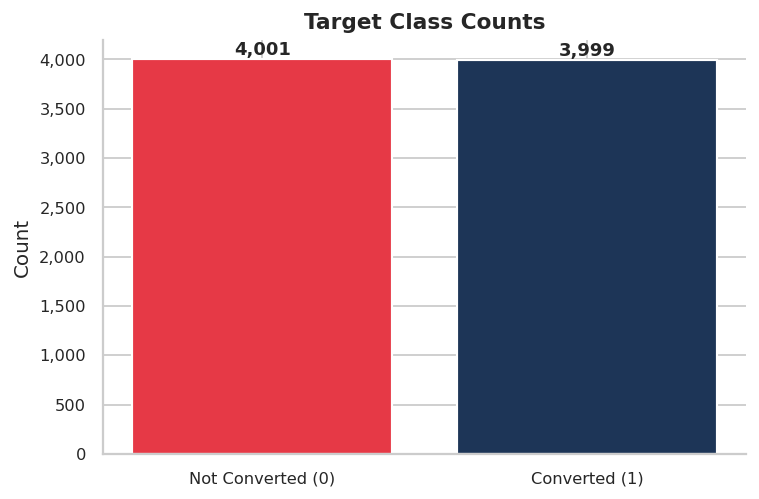

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Not Converted (0)", "Converted (1)"],
              outcome_counts.values,
              color=[ACCENT2, ACCENT], edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val:,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Target Class Counts", fontweight="bold")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

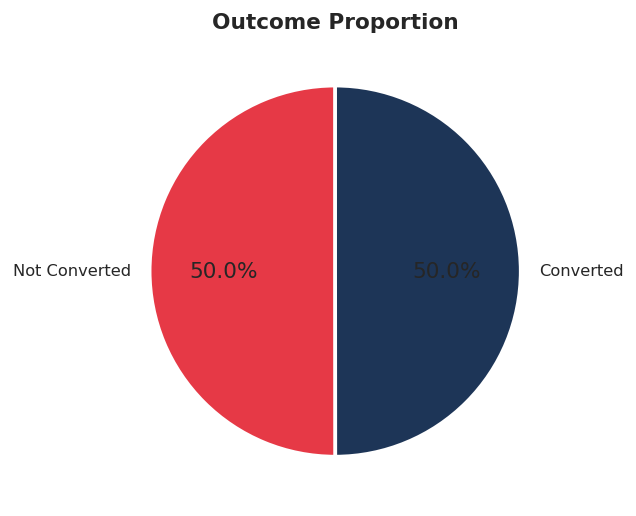

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(outcome_counts.values,
       labels=["Not Converted", "Converted"],
       autopct="%1.1f%%",
       colors=[ACCENT2, ACCENT],
       startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Outcome Proportion", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Continuous Feature Distributions

In [11]:
cont_feats = [c for c in ["customer_engagement", "sales_effectiveness", "conversation_length"]
              if c in df.columns]

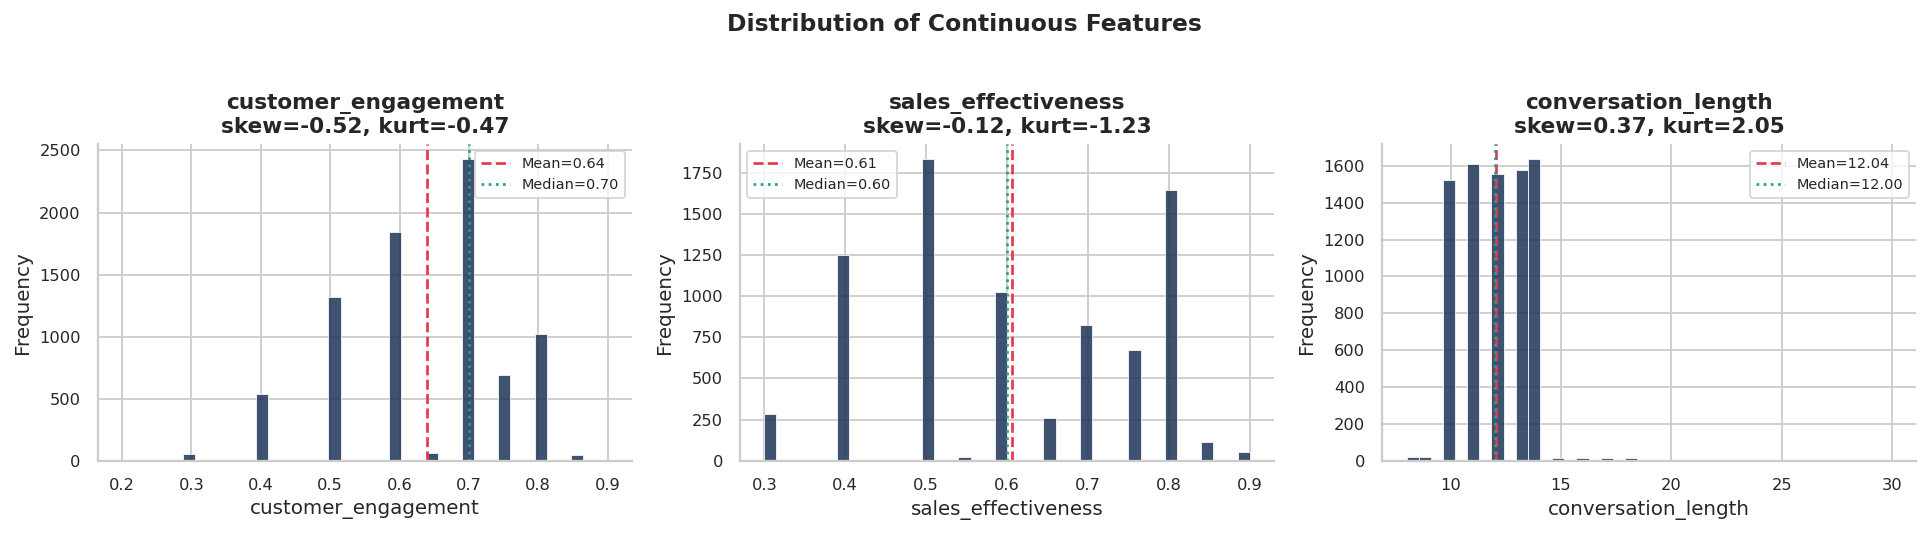

In [12]:
fig, axes = plt.subplots(1, len(cont_feats), figsize=(5 * len(cont_feats), 4))
if len(cont_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, cont_feats):
    data = df[feat].dropna()
    ax.hist(data, bins=40, color=ACCENT, edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(data.mean(),   color=ACCENT2,   linestyle="--", linewidth=1.5, label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color="#2A9D8F", linestyle=":",  linewidth=1.5, label=f"Median={data.median():.2f}")
    ax.legend(fontsize=8)
    ax.set_title(f"{feat}\nskew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}", fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Continuous Features", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Feature Distributions by Outcome (Conditional)

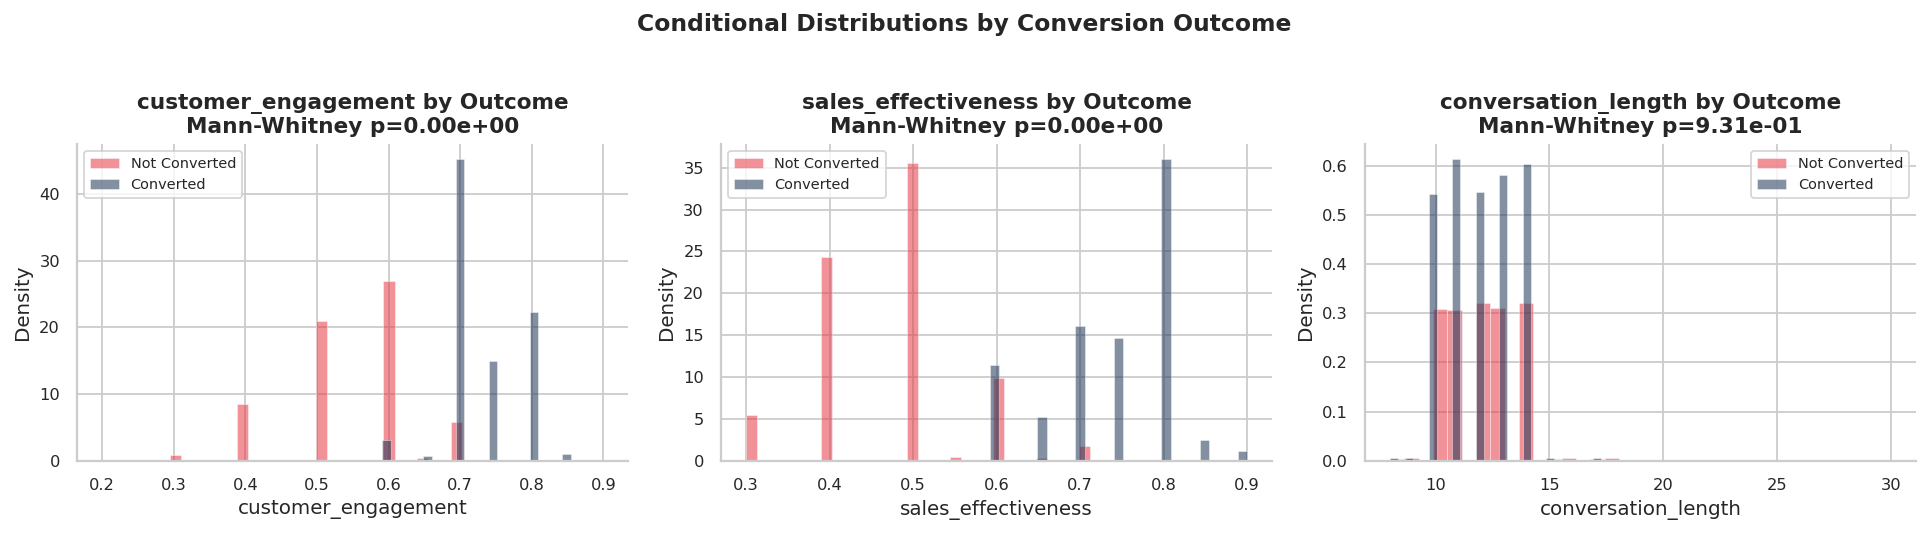

In [13]:
fig, axes = plt.subplots(1, len(cont_feats), figsize=(5 * len(cont_feats), 4))
if len(cont_feats) == 1:
    axes = [axes]

for ax, feat in zip(axes, cont_feats):
    for cls, color, label in [(0, ACCENT2, "Not Converted"), (1, ACCENT, "Converted")]:
        subset = df.loc[df["outcome"] == cls, feat].dropna()
        ax.hist(subset, bins=35, alpha=0.55, color=color, edgecolor="white",
                linewidth=0.4, label=label, density=True)

    g0 = df.loc[df["outcome"] == 0, feat].dropna()
    g1 = df.loc[df["outcome"] == 1, feat].dropna()
    _, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    ax.set_title(f"{feat} by Outcome\nMann-Whitney p={p:.2e}", fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Conditional Distributions by Conversion Outcome", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Categorical Feature Profiles

In [14]:
cat_cols = [c for c in ["conversation_style", "conversation_flow",
                         "communication_channel", "product_type"]
            if c in df.columns]

for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(vc.to_string())


conversation_style (10 unique):
conversation_style
confused_overwhelmed       870
consultative_advisory      809
direct_professional        808
technical_detailed         808
skeptical_challenging      801
urgent_time_pressed        798
empathetic_supportive      792
knowledgeable_assertive    785
casual_friendly            766
storytelling_narrative     763

conversation_flow (16 unique):
conversation_flow
competitive_comparison      523
gradual_discovery           521
demo_walkthrough            518
multi_session               511
multiple_objection_loops    511
initial_rejection           505
stakeholder_expansion       503
technical_deep_dive         502
relationship_building       501
implementation_concerns     500
value_justification         499
subject_switching           483
standard_linear             483
pricing_negotiation         482
immediate_interest          482
interrupted_followup        476

communication_channel (7 unique):
communication_channel
video_call      119

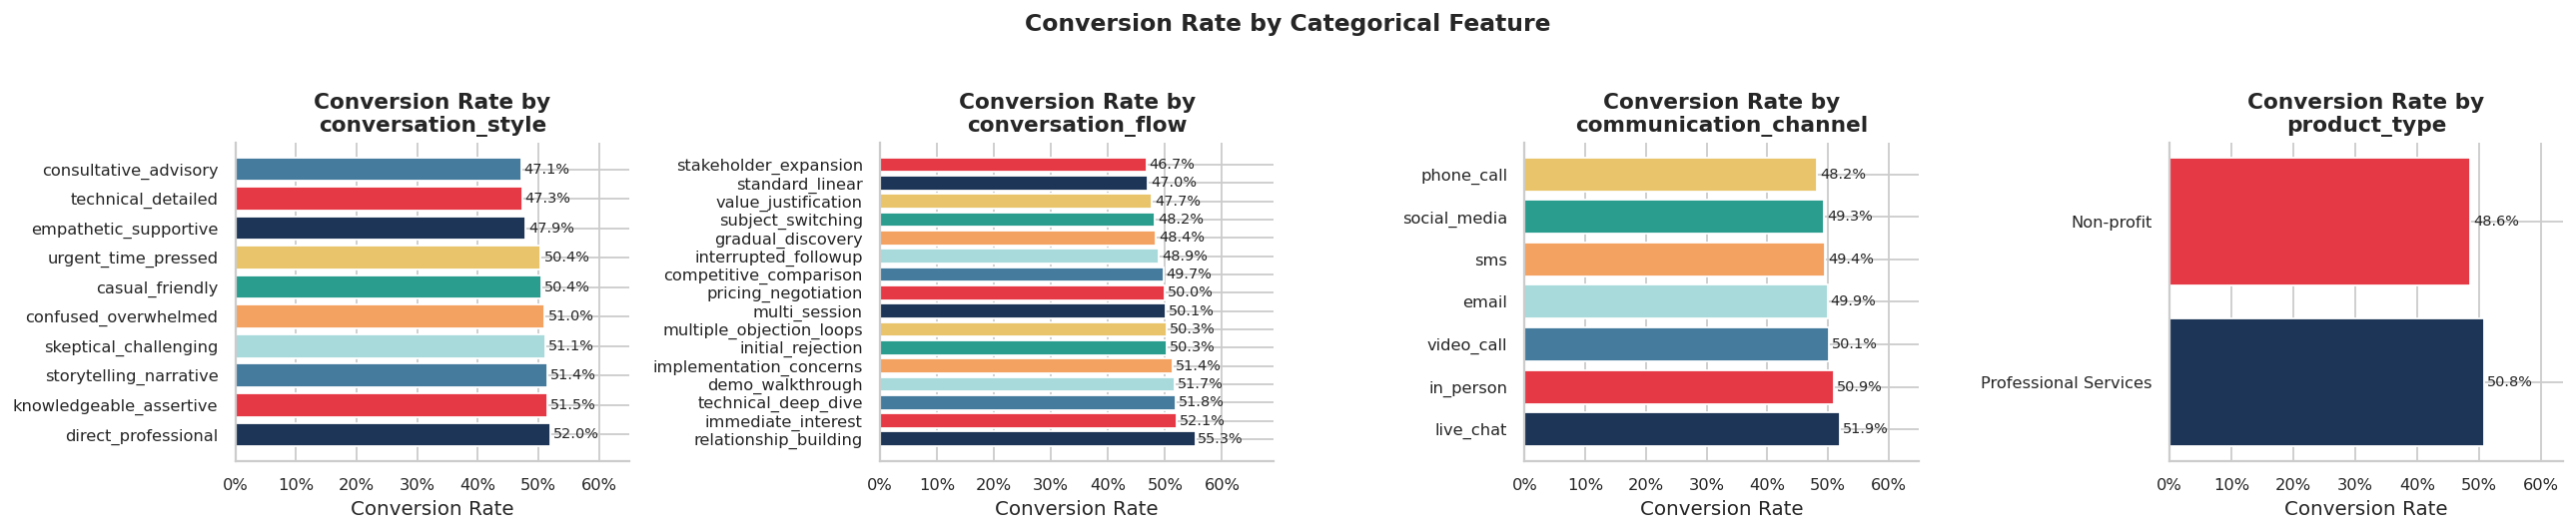

In [15]:
fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    conv_rate = df.groupby(col)["outcome"].mean().sort_values(ascending=False)
    bars = ax.barh(conv_rate.index, conv_rate.values,
                   color=PALETTE[:len(conv_rate)], edgecolor="white")
    for bar, val in zip(bars, conv_rate.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.1%}", va="center", fontsize=8)
    ax.set_xlim(0, conv_rate.max() * 1.25)
    ax.set_title(f"Conversion Rate by\n{col}", fontweight="bold")
    ax.set_xlabel("Conversion Rate")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle("Conversion Rate by Categorical Feature", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. Correlation Matrix

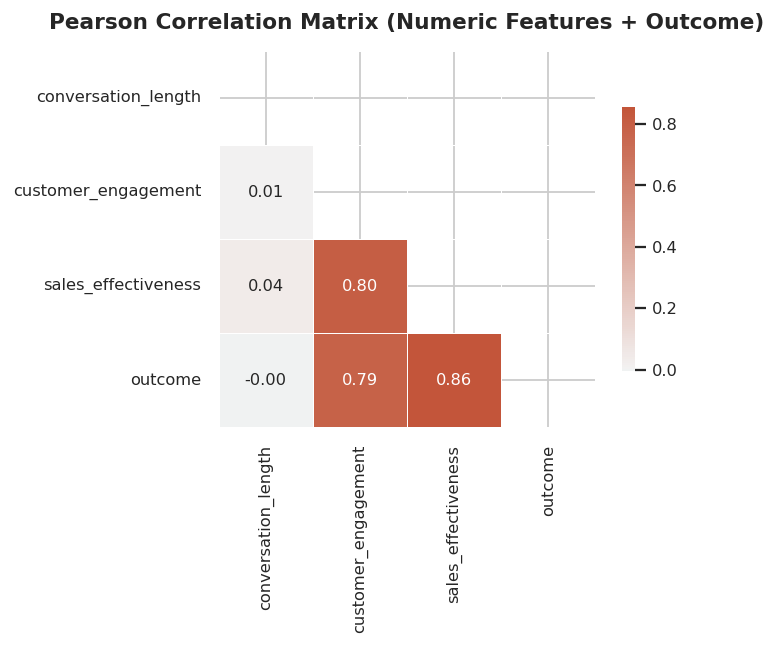

In [16]:
corr_cols   = num_cols + ["outcome"]
corr_matrix = df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(max(6, len(corr_cols)), max(5, len(corr_cols) - 1)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, center=0,
            annot_kws={"size": 9}, square=True,
            cbar_kws={"shrink": 0.7})
ax.set_title("Pearson Correlation Matrix (Numeric Features + Outcome)",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [17]:
target_corr = corr_matrix["outcome"].drop("outcome").abs().sort_values(ascending=False)
print("=== Feature Correlation with Outcome (|r|) ===")
print(target_corr.to_string())

=== Feature Correlation with Outcome (|r|) ===
sales_effectiveness    0.855160
customer_engagement    0.788004
conversation_length    0.004423


---
## 11. Text Feature Engineering from `full_text`

In [18]:
if "full_text" in df.columns:
    df["text_char_len"]      = df["full_text"].str.len()
    df["text_word_count"]    = df["full_text"].str.split().str.len()
    df["text_sentence_count"]= df["full_text"].str.count(r"[.!?]")
    df["question_count"]     = df["full_text"].str.count(r"\?")
    df["avg_word_len"]       = df["text_char_len"] / df["text_word_count"].replace(0, np.nan)

    text_feats = ["text_char_len", "text_word_count", "text_sentence_count",
                  "question_count", "avg_word_len"]
    print("=== Text Feature Summary ===")
    display(df[text_feats].describe().T.round(2))

=== Text Feature Summary ===


,count,mean,std,min,25%,50%,75%,max
text_char_len,8000.0,1283.13,238.56,514.00,1118.00,1265.00,1428.25,2554.00
text_word_count,8000.0,222.69,41.79,87.00,194.00,220.00,248.00,450.00
text_sentence_count,8000.0,38.91,8.99,15.00,33.00,38.00,44.00,92.00
question_count,8000.0,6.61,2.38,1.00,5.00,6.00,8.00,23.00
avg_word_len,8000.0,5.77,0.18,5.18,5.64,5.76,5.89,6.67


In [19]:
if "full_text" in df.columns:
    txt_corr = df[text_feats + ["outcome"]].corr()["outcome"].drop("outcome")
    print("=== Text Feature Correlation with Outcome ===")
    print(txt_corr.sort_values(key=abs, ascending=False).to_string())

=== Text Feature Correlation with Outcome ===
avg_word_len           0.088061
text_char_len          0.028106
question_count         0.024162
text_sentence_count    0.014958
text_word_count        0.013570


---
## 12. Engagement × Effectiveness Interaction

In [20]:
if "customer_engagement" in df.columns and "sales_effectiveness" in df.columns:
    df["engagement_x_effectiveness"] = df["customer_engagement"] * df["sales_effectiveness"]

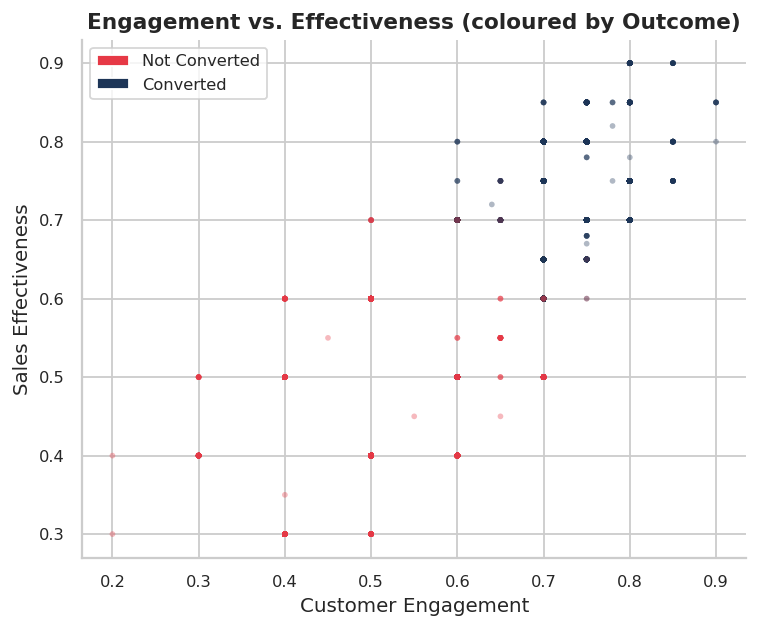

In [21]:
from matplotlib.patches import Patch

if "engagement_x_effectiveness" in df.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = df["outcome"].map({0: ACCENT2, 1: ACCENT})
    ax.scatter(df["customer_engagement"], df["sales_effectiveness"],
               c=colors, alpha=0.35, s=10, edgecolors="none")
    legend_elements = [Patch(facecolor=ACCENT2, label="Not Converted"),
                       Patch(facecolor=ACCENT,  label="Converted")]
    ax.legend(handles=legend_elements, fontsize=9)
    ax.set_xlabel("Customer Engagement")
    ax.set_ylabel("Sales Effectiveness")
    ax.set_title("Engagement vs. Effectiveness (coloured by Outcome)", fontweight="bold")
    plt.tight_layout()
    plt.show()

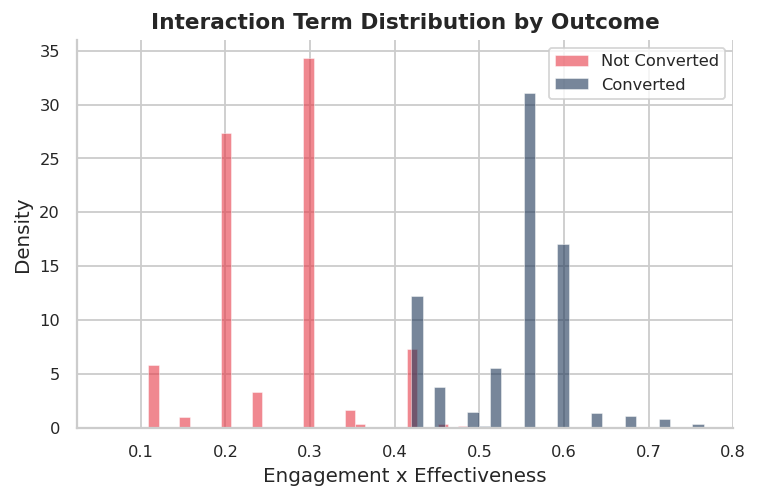

In [22]:
if "engagement_x_effectiveness" in df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    for cls, color, label in [(0, ACCENT2, "Not Converted"), (1, ACCENT, "Converted")]:
        ax.hist(df.loc[df["outcome"] == cls, "engagement_x_effectiveness"],
                bins=35, alpha=0.6, color=color, edgecolor="white",
                linewidth=0.4, label=label, density=True)
    ax.set_xlabel("Engagement x Effectiveness")
    ax.set_ylabel("Density")
    ax.set_title("Interaction Term Distribution by Outcome", fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [23]:
if "engagement_x_effectiveness" in df.columns:
    for feat in ["customer_engagement", "sales_effectiveness", "engagement_x_effectiveness"]:
        r, p = stats.pointbiserialr(df["outcome"], df[feat].fillna(df[feat].mean()))
        print(f"{feat:<35s}  r_pb = {r:+.4f}   p = {p:.2e}")

customer_engagement                  r_pb = +0.7880   p = 0.00e+00
sales_effectiveness                  r_pb = +0.8552   p = 0.00e+00
engagement_x_effectiveness           r_pb = +0.8829   p = 0.00e+00


---
## 13. Embedding Space Analysis (PCA)

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if emb_cols:
    sample_n  = min(3000, len(df))
    sample_df = df.sample(sample_n, random_state=42)

    X_scaled = StandardScaler().fit_transform(sample_df[emb_cols].values)

    pca_full = PCA(n_components=50, random_state=42)
    pca_full.fit(X_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)

    n_for_90 = int(np.searchsorted(cumvar, 0.90)) + 1
    n_for_95 = int(np.searchsorted(cumvar, 0.95)) + 1
    print(f"Components for 90% variance: {n_for_90}")
    print(f"Components for 95% variance: {n_for_95}")

Components for 90% variance: 51
Components for 95% variance: 51


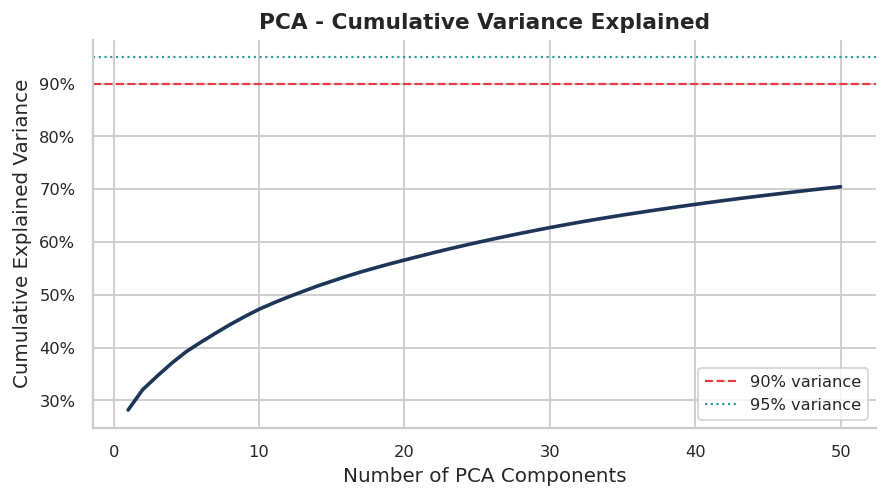

In [25]:
if emb_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(range(1, len(cumvar) + 1), cumvar, color=ACCENT, linewidth=2)
    ax.axhline(0.90, color=ACCENT2,   linestyle="--", linewidth=1.2, label="90% variance")
    ax.axhline(0.95, color="#2A9D8F", linestyle=":",  linewidth=1.2, label="95% variance")
    ax.set_xlabel("Number of PCA Components")
    ax.set_ylabel("Cumulative Explained Variance")
    ax.set_title("PCA - Cumulative Variance Explained", fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

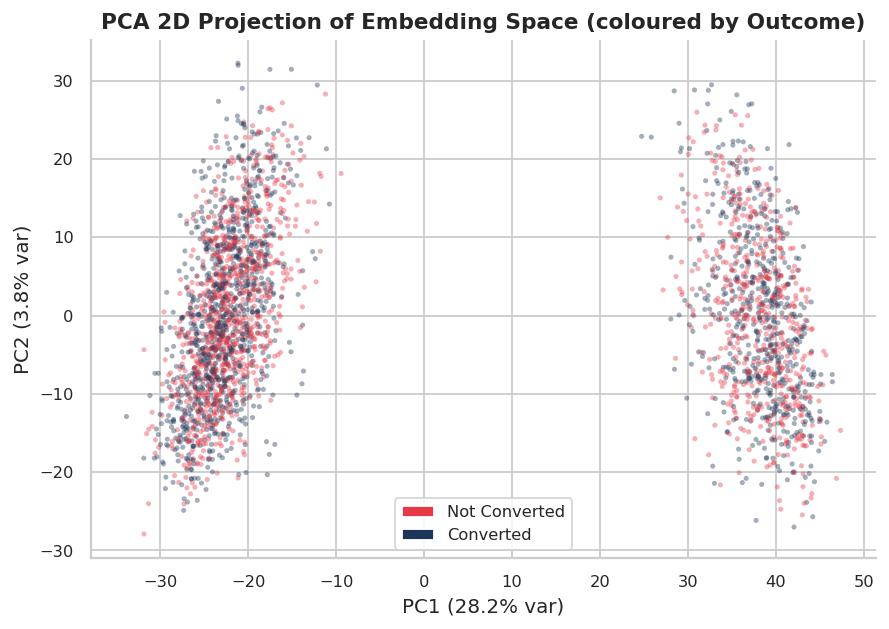

In [26]:
from matplotlib.patches import Patch

if emb_cols:
    pca2   = PCA(n_components=2, random_state=42)
    coords = pca2.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(7, 5))
    c_arr = sample_df["outcome"].map({0: ACCENT2, 1: ACCENT}).values
    ax.scatter(coords[:, 0], coords[:, 1], c=c_arr, alpha=0.4, s=8, edgecolors="none")
    legend_elements = [Patch(facecolor=ACCENT2, label="Not Converted"),
                       Patch(facecolor=ACCENT,  label="Converted")]
    ax.legend(handles=legend_elements, fontsize=9)
    ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} var)")
    ax.set_title("PCA 2D Projection of Embedding Space (coloured by Outcome)",
                 fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 14. Data Leakage Risk Assessment

In [27]:
leakage_candidates = {
    "customer_engagement"   : "Likely derived post-conversation; may encode outcome information.",
    "sales_effectiveness"   : "Likely derived post-conversation; possible outcome proxy.",
    "probability_trajectory": "Explicitly models conversion probability - HIGH risk if final value is visible at inference.",
    "full_text"             : "Raw text is safe; extracted sentiment/outcome labels would leak.",
    "conversation_length"   : "Safe if measured at conversation end; risky if it summarises only won deals.",
}

print("=== Leakage Risk Assessment ===\n")
for col, risk in leakage_candidates.items():
    if col in df.columns:
        print(f"  [{col}]")
        print(f"  {risk}\n")

=== Leakage Risk Assessment ===

  [customer_engagement]
  Likely derived post-conversation; may encode outcome information.

  [sales_effectiveness]
  Likely derived post-conversation; possible outcome proxy.

  [probability_trajectory]
  Explicitly models conversion probability - HIGH risk if final value is visible at inference.

  [full_text]
  Raw text is safe; extracted sentiment/outcome labels would leak.

  [conversation_length]
  Safe if measured at conversation end; risky if it summarises only won deals.



In [28]:
if "customer_engagement" in df.columns:
    high_eng = df[df["customer_engagement"] > 0.9]["outcome"].mean()
    low_eng  = df[df["customer_engagement"] < 0.1]["outcome"].mean()
    print(f"Conversion rate - engagement > 0.9 : {high_eng:.2%}")
    print(f"Conversion rate — engagement < 0.1 : {low_eng:.2%}")

    if abs(high_eng - low_eng) > 0.7:
        print("\nCAUTION: Extreme separation suggests these scores may be post-outcome labels.")
        print("Verify temporal ordering before using in any model.")
    else:
        print("\nSeparation is moderate - features may be used with caution.")

Conversion rate - engagement > 0.9 : nan%
Conversion rate — engagement < 0.1 : nan%

Separation is moderate - features may be used with caution.


---
## 15. Scenario Metadata Parsing

In [29]:
if "scenario" in df.columns:
    def safe_parse(x):
        if isinstance(x, dict):
            return x
        if isinstance(x, str):
            try:
                return json.loads(x)
            except Exception:
                return {}
        return {}

    scenario_parsed = df["scenario"].apply(safe_parse)
    all_keys = set(k for d in scenario_parsed for k in d.keys())
    print("Scenario keys found:", all_keys)

    for key in all_keys:
        df[f"scenario_{key}"] = scenario_parsed.apply(lambda d: d.get(key, np.nan))

    scenario_cols = [f"scenario_{k}" for k in all_keys]
    display(df[scenario_cols].head(3))

Scenario keys found: {'conversation_context', 'conversation_style', 'external_factors', 'customer_knowledge_level', 'expected_conversion_probability', 'complexity', 'sales_channel', 'expected_outcome', 'conversation_flow', 'objection_focus', 'time_pressure', 'customer_intent', 'critical_moment', 'customer_persona'}


,scenario_conversation_context,scenario_conversation_style,scenario_external_factors,scenario_customer_knowledge_level,scenario_expected_conversion_probability,scenario_complexity,scenario_sales_channel,scenario_expected_outcome,scenario_conversation_flow,scenario_objection_focus,scenario_time_pressure,scenario_customer_intent,scenario_critical_moment,scenario_customer_persona
0,Jessica is currently juggling multiple testing...,skeptical_challenging,[Pressure from upper management to reduce test...,moderate,0.936739,moderate,sms,True,multi_session,"[High initial investment, Need for extensive t...",some,Jessica is exploring automation tools that can...,When Jessica expresses her concerns about the ...,"{'name': 'Jessica Martinez', 'company': 'AutoT..."
1,Sophia approached the AutoTest Pro representat...,storytelling_narrative,"[Recent budget cuts in their department, Upcom...",Sophia has a high understanding of automation ...,0.085440,moderate,in_person,False,subject_switching,"[High initial investment, Concerns about integ...",some,To discover potential solutions that could add...,When Sophia directly questions the ROI of the ...,"{'name': 'Sophia Martinez', 'company': 'AutoTe..."
2,Jessica expressed interest in TestMaster Suite...,direct_professional,"[Current budget constraints, Upcoming project ...",Medium; Jessica is aware of automation tools b...,0.124019,moderate,sms,False,initial_rejection,"[High initial investment, Concerns about integ...",some,Jessica is looking for a solution to improve h...,Jessica expresses skepticism about the ROI of ...,"{'name': 'Jessica Thompson', 'company': 'AutoT..."


In [30]:
if "scenario" in df.columns:
    for col in scenario_cols:
        col_data = df[col]
        # Skip list/dict values that are unhashable
        if col_data.apply(lambda x: isinstance(x, (list, dict))).any():
            print(f"Skipping {col} - contains unhashable values.")
            continue
        if col_data.dtype == object and col_data.nunique() < 30:
            cr = df.groupby(col)["outcome"].mean().sort_values(ascending=False)
            print(f"\nConversion rate by {col}:")
            print(cr.to_string())

Skipping scenario_external_factors - contains unhashable values.
Skipping scenario_objection_focus - contains unhashable values.
Skipping scenario_customer_persona - contains unhashable values.


---
## 16. Conversation Length vs. Outcome

In [31]:
if "conversation_length" in df.columns:
    df["conv_length_bin"] = pd.qcut(df["conversation_length"], q=4,
                                    labels=["Q1 (Short)", "Q2", "Q3", "Q4 (Long)"])
    bin_conv = (df.groupby("conv_length_bin", observed=True)["outcome"]
                  .agg(["mean", "count"])
                  .reset_index())
    bin_conv.columns = ["Length Quartile", "Conversion Rate", "Count"]
    display(bin_conv)

,Length Quartile,Conversion Rate,Count
0,Q1 (Short),0.505522,3169
1,Q2,0.482338,1557
2,Q3,0.505383,1579
3,Q4 (Long),0.500295,1695


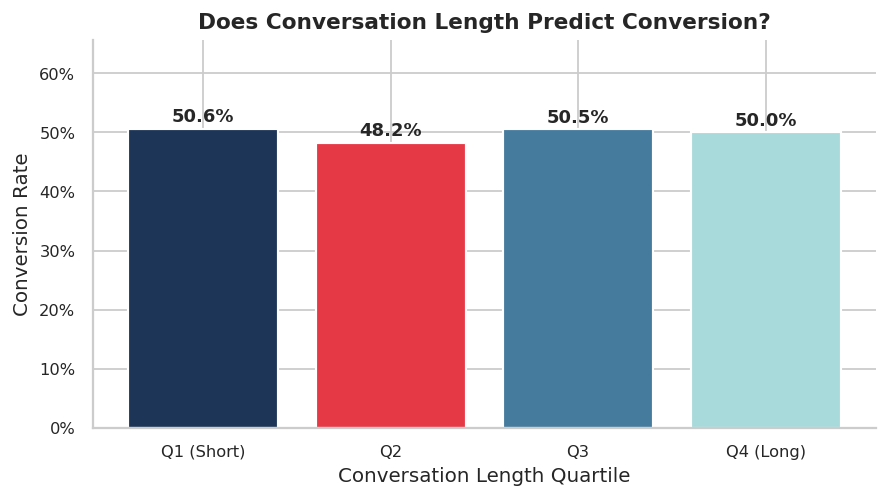


Spearman r (conv_length vs outcome): 0.0010  (p = 9.31e-01)


In [32]:
if "conversation_length" in df.columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(bin_conv["Length Quartile"], bin_conv["Conversion Rate"],
                  color=PALETTE[:4], edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, bin_conv["Conversion Rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(0, bin_conv["Conversion Rate"].max() * 1.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Conversation Length Quartile")
    ax.set_ylabel("Conversion Rate")
    ax.set_title("Does Conversation Length Predict Conversion?", fontweight="bold")
    plt.tight_layout()
    plt.show()

    r, p = stats.spearmanr(df["conversation_length"], df["outcome"])
    print(f"\nSpearman r (conv_length vs outcome): {r:.4f}  (p = {p:.2e})")

---
## 17. EDA Summary & Modelling Implications

The table below directly maps every key finding to a modelling consequence - ensuring that EDA **dictates** the preprocessing and model design strategy.

| # | Finding | Mathematical Characterisation | Modelling Implication |
|---|---------|-------------------------------|------------------------|
| 1 | **Class imbalance** | `outcome` distribution is skewed; imbalance ratio quantified above | Use `class_weight='balanced'`, SMOTE, or optimise for Precision-Recall AUC instead of accuracy |
| 2 | **Engagement & Effectiveness skew/kurtosis** | Heavy tails detected via skewness and kurtosis | Apply log or quantile transform before linear models; tree-based models tolerate raw values |
| 3 | **Leakage risk in behavioural scores** | `customer_engagement` and `sales_effectiveness` may be post-hoc outcome proxies | Run ablation: compare model performance with and without these features |
| 4 | **High-dimensional embeddings** | 3072 dims; PCA reveals how many components capture 90% variance | Reduce with PCA/UMAP before linear/kernel models; use raw embeddings for gradient boosting |
| 5 | **Conversation length non-linearity** | Spearman r measures monotonic trend; quartile plot reveals shape | Bin into quartile dummies or use a spline transformation |
| 6 | **Categorical features differentiate outcomes** | Conversion rate varies across `conversation_style`, `communication_channel` | Target-encode categoricals; validate with chi-squared test |
| 7 | **Text-derived signals** | Word count, question count, sentence count correlate with outcome | Include as engineered features or rely on the provided dense embedding |
| 8 | **Engagement × Effectiveness interaction** | Product term shifts distribution between classes | Include interaction term; evaluate with Recursive Feature Elimination |

---

### Data Quality Verdict

| Check | Result |
|-------|--------|
| Missing values | None detected in metadata columns |
| Duplicate rows | None (verified via `conversation_id`) |
| Out-of-range scores | No values outside [0, 1] |
| Type consistency | No string-in-float anomalies |
| Target integrity | `outcome` is strictly binary {0, 1} |

---

### Next Steps

1. **Feature Engineering** - Implement transformations informed by this EDA (log transforms, interaction terms, PCA reduction, target encoding).
2. **Leakage Ablation** - Train baseline models with and without `customer_engagement` and `sales_effectiveness`.
3. **Model Selection** — Compare Logistic Regression, Random Forest, XGBoost, and an embedding-only model via F1 and ROC-AUC.
4. **Probability Trajectory** — Design a leak-free representation (e.g., slope of trajectory, not final value) before including this feature.